# Optimization Attempts

## Piecewise Linear, random initial condition for optimization

### Setup

In [2]:

### Week 05: The 2D Wing -- Connecting Shape to Amplitude
## CELL 2 - Setup
import os, subprocess, sys

# Keep this path if working in Colab
# repo_path = "/content/butterflai"

# Use this path if working locally
repo_path = "../../"

if not os.path.isdir(repo_path):
    subprocess.run(["git", "clone", "https://github.com/SwRI-IDEA-Lab/butterflai.git", repo_path], check=True)
else:
    subprocess.run(["git", "-C", repo_path, "pull"], check=True)
sys.path.insert(0, repo_path)
from infrastructure.utils.colab_setup import setup
setup()


Already up to date.
  Installing from /home/russell/ButterflAI/butterflai/requirements.txt...

🦋 ButterflAI environment ready
   Runtime  : Local
   Device   : cuda
   Seed     : 42


{'in_colab': False,
 'device': device(type='cuda'),
 'seed': 42,
 'drive_mounted': False,
 'data_path': None}

In [3]:

### 1) Load data
## CELL 4 - import libraries and load data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
from pathlib import Path
from scipy.stats import norm as sp_norm
from scipy.optimize import curve_fit, minimize_scalar, minimize

# data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_daily_measurements_10_23.csv'
data_path = Path(repo_path) / 'data' / 'composite_sunspot_groups_peak_area.csv'
# df = pd.read_csv(data_path, parse_dates=[[0, 1, 2]], keep_date_col=False)
df = pd.read_csv(data_path)
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])
df = df.drop(['year', 'month', 'day'], axis=1)
df.rename(columns={"year_month_day": "date"}, inplace=True)
df = df[df["latitude"].notna()].copy()

df["hemisphere"]   = df["latitude"].apply(lambda v: "north" if v >= 0 else "south")
df["abs_latitude"] = df["latitude"].abs()
df["year"] = df["date"].dt.year
df["decimal_year"] = df["date"].dt.year + df["date"].dt.dayofyear / 365.25

# Remove pores and small objects
df = df[df["correctedArea"] > 30].copy()

# df.head()


In [4]:

### 2) Standardize time: align cycles at the 15 degree crossing
## CELL 7 - Align data at 15 deg crossing
t0_lookup = {}
for (cyc, hemi), group in df.groupby(["CYCLE", "hemisphere"]):
    yearly_mean = group.groupby("year")["abs_latitude"].mean().sort_index()
    years, means = yearly_mean.index.values, yearly_mean.values
    below = means < 15.0
    if not below.any() or below.all():
        continue
    idx1 = np.argmax(below)
    if idx1 == 0:
        continue
    y0, mu0 = years[idx1 - 1], means[idx1 - 1]
    y1, mu1 = years[idx1],     means[idx1]
    t0_lookup[(cyc, hemi)] = y0 + (15.0 - mu0) / (mu1 - mu0)

df["t0"]  = df.apply(lambda r: t0_lookup.get((r["CYCLE"], r["hemisphere"]), np.nan), axis=1)
df["tau"] = df["decimal_year"] - df["t0"]


In [5]:

### 3) Fit a universal mean path mu(tau) and refine the time origin
## CELL 9 - Fit a uiversal mean path and refine time origin
def exp_decay(tau, a, b):
    return a * np.exp(-tau / b)

N_BINS_13   = 20
cycles_13   = [c for c in sorted(df["CYCLE"].dropna().unique()) if c >= 12]
# cmap_13     = cm.get_cmap("tab20", len(cycles_13))
cyc_idx_13  = {c: i for i, c in enumerate(cycles_13)}

all_tau_bins, all_mu_bins = [], []
hemicycle_bins_13 = {}

for cyc in cycles_13:
    for hemi in ["north", "south"]:
        if (cyc, hemi) not in t0_lookup:
            continue
        mask   = (df["CYCLE"] == cyc) & (df["hemisphere"] == hemi) & df["tau"].notna()
        df_sel = df[mask]
        if len(df_sel) < 50:
            continue
        t_min, t_max = df_sel["tau"].min(), df_sel["tau"].max()
        bins        = np.linspace(t_min, t_max, N_BINS_13 + 1)
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        bt, bm = [], []
        for i in range(N_BINS_13):
            lats_bin = df_sel.loc[
                (df_sel["tau"] >= bins[i]) & (df_sel["tau"] < bins[i + 1]),
                "abs_latitude"].values
            if len(lats_bin) < 10:
                continue
            mu_f, _ = sp_norm.fit(lats_bin)
            bt.append(bin_centers[i]); bm.append(mu_f)
        if len(bt) < 5:
            continue
        bt = np.array(bt); bm = np.array(bm)
        hemicycle_bins_13[(cyc, hemi)] = (bt, bm)
        all_tau_bins.extend(bt); all_mu_bins.extend(bm)

popt_global, _ = curve_fit(exp_decay, all_tau_bins, all_mu_bins, p0=[15.0, 5.0])
a_mu_univ, b_mu_univ = popt_global
print(f"Universal μ(τ):  a = {a_mu_univ:.2f}°   b = {b_mu_univ:.2f} yr")
print(f"μ(τ) = {a_mu_univ:.2f} * exp(-τ / {b_mu_univ:.2f})")

# Refine t₀ per hemisphere-cycle
t0_refined = {}
for (cyc, hemi), (bt, bm) in hemicycle_bins_13.items():
    def _res(dt, _bt=bt, _bm=bm):
        return np.sum((_bm - exp_decay(_bt - dt, a_mu_univ, b_mu_univ)) ** 2)
    res = minimize_scalar(_res, bounds=(-4, 4), method="bounded")
    t0_refined[(cyc, hemi)] = t0_lookup[(cyc, hemi)] + res.x

df["t0_refined"]  = df.apply(lambda r: t0_refined.get((r["CYCLE"], r["hemisphere"]), np.nan), axis=1)
df["tau_refined"] = df["decimal_year"] - df["t0_refined"]


Universal μ(τ):  a = 16.34°   b = 8.49 yr
μ(τ) = 16.34 * exp(-τ / 8.49)


In [6]:

### 4) Model sigma(mu): spread as a function of mean latitude
## CELL 12 - Model standard deviation as a function of mean latitude
def split_normal_mu(mu, A, mu_peak, s_L, s_R):
    return np.where(
        mu >= mu_peak,
        A * np.exp(-0.5 * ((mu - mu_peak) / s_L) ** 2),
        A * np.exp(-0.5 * ((mu - mu_peak) / s_R) ** 2),
    )

N_BINS_15 = 20
MU_GRID   = np.linspace(2, 42, 300)
results_15 = []

for cyc in cycles_13:
    for hemi in ["north", "south"]:
        if (cyc, hemi) not in t0_refined:
            continue
        mask   = (df["CYCLE"] == cyc) & (df["hemisphere"] == hemi) & df["tau_refined"].notna()
        df_sel = df[mask]
        if len(df_sel) < 50:
            continue
        t_min, t_max = df_sel["tau_refined"].min(), df_sel["tau_refined"].max()
        bins        = np.linspace(t_min, t_max, N_BINS_15 + 1)
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        bm_list, bs_list = [], []
        for i in range(N_BINS_15):
            lats_bin = df_sel.loc[
                (df_sel["tau_refined"] >= bins[i]) & (df_sel["tau_refined"] < bins[i + 1]),
                "abs_latitude"].values
            if len(lats_bin) < 10:
                continue
            mu_f, sigma_f = sp_norm.fit(lats_bin)
            bm_list.append(mu_f); bs_list.append(sigma_f)
        if len(bm_list) < 5:
            continue
        bm_arr = np.array(bm_list); bs_arr = np.array(bs_list)
        sidx = np.argsort(bm_arr)
        bm_arr, bs_arr = bm_arr[sidx], bs_arr[sidx]
        try:
            p0 = [bs_arr.max(), bm_arr[np.argmax(bs_arr)], 5.0, 4.0]
            popt, _ = curve_fit(split_normal_mu, bm_arr, bs_arr, p0=p0, maxfev=10_000)
            A_f, mu_peak_f, sL_f, sR_f = popt
        except RuntimeError:
            continue
        if not (0.5 < A_f < 20 and 2 < mu_peak_f < 38 and 0.5 < sL_f < 20 and 0.5 < sR_f < 20):
            continue
        results_15.append(dict(
            cycle=cyc, hemisphere=hemi,
            A=A_f, mu_peak=mu_peak_f, sL=sL_f, sR=sR_f,
            sigma_curve=split_normal_mu(MU_GRID, A_f, mu_peak_f, sL_f, sR_f),
            bin_mu=bm_arr, bin_sigma=bs_arr,
        ))

print(f"Fitted {len(results_15)} hemisphere-cycles.")


Fitted 15 hemisphere-cycles.


In [7]:

### 5) Universal piecewise-linear envelope
## CELL 14 - model the standard deviation using a piecewise-linear approach
def piecewise_linear_wing(mu, m_shared, b_shared, mu_peak, m_i):
    """Universal equatorward line + per-cycle poleward line, joined continuously at mu_peak."""
    sigma_peak = m_shared * mu_peak + b_shared
    b_per = sigma_peak - m_i * mu_peak
    return np.clip(
        np.where(mu <= mu_peak, m_shared * mu + b_shared, m_i * mu + b_per),
        0.0, None
    )

# Bootstrap: fit the shared equatorward line from pooled equatorward-side points
eq_mu, eq_sigma = [], []
for r in results_15:
    mask = r["bin_mu"] <= r["mu_peak"]
    eq_mu.extend(r["bin_mu"][mask]); eq_sigma.extend(r["bin_sigma"][mask])
m_init, b_init = np.polyfit(eq_mu, eq_sigma, 1)
m_i_init = np.mean([-r["A"] / (2 * max(r["sL"], 1.0)) for r in results_15])

# Joint L-BFGS-B optimisation
n_hc = len(results_15)

def residuals_pl(x):
    m_sh, b_sh = x[0], x[1]
    return sum(
        np.sum((r["bin_sigma"] - piecewise_linear_wing(
            r["bin_mu"], m_sh, b_sh, x[2 + 2*i], x[3 + 2*i])) ** 2)
        for i, r in enumerate(results_15)
    )

x0 = np.array([m_init, b_init] + [val for r in results_15
                                   for val in (r["mu_peak"], m_i_init)])
bounds = list(zip(
    [0.0, -5.0] + [2.0, -5.0] * n_hc,
    [2.0,  5.0] + [38.0, 0.0] * n_hc,
))
opt = minimize(residuals_pl, x0, method="L-BFGS-B", bounds=bounds)

m_shared_fit, b_shared_fit = opt.x[0], opt.x[1]
print(f"Universal line:  σ(μ) = {m_shared_fit:.4f}·μ + {b_shared_fit:.4f}")
print(f"Zero crossing at μ = {-b_shared_fit / m_shared_fit:.2f}°")

# Reconstruct per-cycle fitted curves
MU_GRID_PL = np.linspace(2, 42, 300)
results_pl = []
for i, r in enumerate(results_15):
    mu_peak_i    = opt.x[2 + 2*i]
    m_i          = opt.x[3 + 2*i]
    sigma_peak_i = m_shared_fit * mu_peak_i + b_shared_fit
    results_pl.append(dict(
        cycle=r["cycle"], hemisphere=r["hemisphere"],
        m_shared=m_shared_fit, b_shared=b_shared_fit,
        mu_peak=mu_peak_i, m_i=m_i, sigma_peak=sigma_peak_i,
        sigma_curve=piecewise_linear_wing(
            MU_GRID_PL, m_shared_fit, b_shared_fit, mu_peak_i, m_i),
        bin_mu=r["bin_mu"], bin_sigma=r["bin_sigma"],
    ))

# RMSE comparison
def rmse_sn(res_list):
    return np.sqrt(np.mean([
        np.mean((r["bin_sigma"] - split_normal_mu(
            r["bin_mu"], r["A"], r["mu_peak"], r["sL"], r["sR"])) ** 2)
        for r in res_list
    ]))

def rmse_pl(res_list):
    return np.sqrt(np.mean([
        np.mean((r["bin_sigma"] - piecewise_linear_wing(
            r["bin_mu"], r["m_shared"], r["b_shared"], r["mu_peak"], r["m_i"])) ** 2)
        for r in res_list
    ]))

rmse_15 = rmse_sn(results_15)
rmse_16 = rmse_pl(results_pl)
print(f"RMSE — split-normal independent : {rmse_15:.3f}°")
print(f"RMSE — piecewise-linear joint   : {rmse_16:.3f}°  ({(rmse_16 - rmse_15)/rmse_15*100:+.1f}%)")

# Numeric summary
mu_peaks  = [r["mu_peak"]    for r in results_pl]
sig_peaks = [r["sigma_peak"] for r in results_pl]
m_is    = [r["m_i"]      for r in results_pl]
print(f"\nPer-cycle variability:")
print(f"  μ_peak : {np.mean(mu_peaks):.2f}° ± {np.std(mu_peaks):.2f}°  ← detachment latitude")
print(f"  σ_peak : {np.mean(sig_peaks):.2f}° ± {np.std(sig_peaks):.2f}°  ← derived amplitude")
print(f"  m_i  : {np.mean(m_is):.4f} ± {np.std(m_is):.4f}  ← per-cycle poleward slope")


Universal line:  σ(μ) = 0.4429·μ + -0.1495
Zero crossing at μ = 0.34°
RMSE — split-normal independent : 0.845°
RMSE — piecewise-linear joint   : 0.886°  (+4.9%)

Per-cycle variability:
  μ_peak : 16.58° ± 1.46°  ← detachment latitude
  σ_peak : 7.19° ± 0.65°  ← derived amplitude
  m_i  : -0.4018 ± 0.2001  ← per-cycle poleward slope


### Code to Optimize

In [8]:

### Week 05 Exercises: From Wing Shape to a Full Synthetic Cycle
### Task 17 -- Solar Cycle Amplitude from Total Sunspot Area
## CELL 16 - Find solar cycle amplitude

#   - Changed cycle filter to start at startCycle
startCycle = 12

# Task 17: Solar Cycle Amplitude from Total Sunspot Area

# Filter: cycles ≥ startCycle and correctedArea > 50 MSH
df_amp = df[(df["CYCLE"] >= startCycle) & (df["correctedArea"] > 50)].copy()

# Daily total corrected area per hemisphere
daily_north = df_amp[df_amp["hemisphere"] == "north"].groupby("date")["correctedArea"].sum()
daily_south = df_amp[df_amp["hemisphere"] == "south"].groupby("date")["correctedArea"].sum()

# Reindex to a complete daily grid so rolling windows are contiguous (fill 0 for no-sunspot days)
date_range_17 = pd.date_range(
    min(daily_north.index.min(), daily_south.index.min()),
    max(daily_north.index.max(), daily_south.index.max()),
    freq="D",
)
daily_north = daily_north.reindex(date_range_17, fill_value=0)
daily_south = daily_south.reindex(date_range_17, fill_value=0)

# Rolling averages: approximate month lengths in days
windows_17 = {"3 mo": 91, "6 mo": 182, "12 mo": 365, "24 mo": 730}
line_styles = [("tab:blue", 1.0), ("tab:orange", 1.2), ("tab:green", 1.6), ("tab:red", 2.0)]

# fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
# for ax, hemi_label, daily in zip(axes, ["North", "South"], [daily_north, daily_south]):
for hemi_label, daily in zip(["North", "South"], [daily_north, daily_south]):
    for (label, win), (col, lw) in zip(windows_17.items(), line_styles):
        smoothed = daily.rolling(win, center=True, min_periods=win // 3).mean()



### Task 18 — Peak Amplitude and Timing of Each Hemispheric Cycle
## CELL 18 - Detect peaks in the smoothed sunspot area
# Task 18: Peak Amplitude and Timing of Each Hemispheric Cycle

WIN_18 = 365  # window chosen from Task 17 - in integer days

smooth_north = daily_north.rolling(WIN_18, center=True, min_periods=WIN_18 // 3).mean()
smooth_south = daily_south.rolling(WIN_18, center=True, min_periods=WIN_18 // 3).mean()

# For each (cycle, hemisphere), find the date and value of the smoothed-area maximum
# within the calendar span of that cycle's sunspot records.
peak_records = []
for cyc in cycles_13:
    cyc_dates = df[df["CYCLE"] == cyc]["date"]
    if len(cyc_dates) == 0:
        continue
    d_min, d_max = cyc_dates.min(), cyc_dates.max()
    for hemi, smooth in [("north", smooth_north), ("south", smooth_south)]:
        seg = smooth[(smooth.index >= d_min) & (smooth.index <= d_max)].dropna()
        if len(seg) == 0:
            continue
        peak_records.append(dict(
            cycle=int(cyc), hemisphere=hemi,
            peak_date=seg.idxmax(),
            peak_amplitude=float(seg.max()),
        ))

peaks_df = (pd.DataFrame(peak_records)
            .sort_values(["cycle", "hemisphere"])
            .reset_index(drop=True))



### Task 19 -- Relating Cycle Amplitude to Wing Shape Parameters
## CELL 20 - Use linear fits to approximate the relationship between cycle amplitude and wing shape parameters
# Task 19: Relating Cycle Amplitude to Wing Shape Parameters

def linear_fit(x, a, b):
    return a * x + b

# Build (cycle, hemisphere) → peak amplitude lookup from Task 18
amp_lookup = {
    (row["cycle"], row["hemisphere"]): row["peak_amplitude"]
    for _, row in peaks_df.iterrows()
}

# Assemble: shape params from Section 5  +  amplitude from Task 18
# μ₀ = value of the universal mean path at the *minimum* τ_refined observed
# for that hemisphere-cycle — the latitude where the cycle first shows activity.
records_19 = []
for r in results_pl:
    cyc, hemi = r["cycle"], r["hemisphere"]
    amp = amp_lookup.get((int(cyc), hemi))
    if amp is None or np.isnan(amp):
        continue
    mask = (df["CYCLE"] == cyc) & (df["hemisphere"] == hemi) & df["tau_refined"].notna()
    df_sel = df[mask]
    if len(df_sel) == 0:
        continue
    tau_start = df_sel["tau_refined"].min()
    mu0 = float(exp_decay(tau_start, a_mu_univ, b_mu_univ))
    records_19.append(dict(
        cycle=int(cyc), hemisphere=hemi,
        amplitude=float(amp), mu0=mu0,
        mu_peak=float(r["mu_peak"]),
        m_i=float(r["m_i"]),
    ))

df19 = pd.DataFrame(records_19)
# print(df19.to_string(index=False))

# ── Scatter plots + linear fits ───────────────────────────────────────────
param_info = [
    ("mu0",     r"$\mu_0$ — earliest mean latitude (°)",    "tab:purple"),
    ("mu_peak", r"$\mu_{\rm peak}$ — detachment latitude (°)", "tab:orange"),
    ("m_i",     r"$m_i$ — poleward slope",                   "tab:green"),
]

fit_results_19 = {}
for (col, ylabel, color) in param_info:
    vals = df19[["amplitude", col]].dropna()
    x, y = vals["amplitude"].values, vals[col].values
    popt, _ = curve_fit(linear_fit, x, y, p0=[0.0, float(np.mean(y))])
    a_fit, b_fit = popt
    fit_results_19[col] = (a_fit, b_fit)

print("\nFitted linear relationships:")
for col, (a, b) in fit_results_19.items():
    print(f"  {col:8s} = {a:+.6f} · A  +  {b:.3f}")

print()

### Setup: compute_global_nll -- A Single Number to Rule Them All
## CELL 26 - define compute_global_nll and create the global data cache
# Setup: pre-compute cycle data cache and define the global scoreboard metric.
# Run this cell once before executing Tasks 21–24.

df19_records_global = []
cycle_data_global   = []
for rec in df19.to_dict("records"):
    cyc, hemi = rec["cycle"], rec["hemisphere"]
    A = amp_lookup.get((int(cyc), hemi))
    if A is None:
        continue
    df_ch = df[(df["CYCLE"] == cyc) & (df["hemisphere"] == hemi)]
    years_data = []
    for yr in sorted(df_ch["year"].unique()):
        tau  = (yr + 0.5) - t0_refined[(int(cyc), hemi)]
        mu   = exp_decay(tau, a_mu_univ, b_mu_univ)
        lats = df_ch.loc[df_ch["year"] == yr, "latitude"].abs().values
        if len(lats) >= 5:
            years_data.append((tau, mu, lats))
    if years_data:
        df19_records_global.append(rec)
        cycle_data_global.append((A, years_data))


def compute_global_nll(fit_results, m_sh=None, b_sh=None):
    """
    Mean per-year-normalized NLL across all hemisphere-cycles — the scoreboard metric.

    Parameters
    ----------
    fit_results : dict with keys 'mu0', 'mu_peak', 'm_i'
        Each value is a (slope, intercept) tuple: param(A) = slope * A + intercept.
        Same format as fit_results_19 from Task 19.
    m_sh, b_sh : float, optional
        Override the universal equatorial line parameters.
        Defaults to m_shared_fit / b_shared_fit from Section 5.

    Returns
    -------
    float — lower is better.  Units: nats/year.
    """
    if m_sh is None: m_sh = m_shared_fit
    if b_sh is None: b_sh = b_shared_fit
    a_mu0,    b_mu0    = fit_results["mu0"]
    a_mupeak, b_mupeak = fit_results["mu_peak"]
    a_mi,     b_mi     = fit_results["m_i"]
    total, n_terms = 0.0, 0
    for A, years_data in cycle_data_global:
        mu0_p    = a_mu0 * A + b_mu0
        mupeak_p = a_mupeak * A + b_mupeak
        mi_p     = a_mi * A + b_mi
        for tau, mu, lats in years_data:
            if mu > mu0_p:
                continue
            sigma = piecewise_linear_wing(mu, m_sh, b_sh, mupeak_p, mi_p)
            if sigma <= 0:
                continue
            total -= sp_norm.logpdf(lats, loc=mu, scale=sigma).mean()
            n_terms += 1
    return total / max(n_terms, 1)

def compute_global_nll_optMod(fit_results, m_sh=None, b_sh=None):
    """
    Mean per-year-normalized NLL across all hemisphere-cycles — the scoreboard metric.
    Modified for optimization to report large numbers when n_terms is 0.

    Parameters
    ----------
    fit_results : dict with keys 'mu0', 'mu_peak', 'm_i'
        Each value is a (slope, intercept) tuple: param(A) = slope * A + intercept.
        Same format as fit_results_19 from Task 19.
    m_sh, b_sh : float, optional
        Override the universal equatorial line parameters.
        Defaults to m_shared_fit / b_shared_fit from Section 5.

    Returns
    -------
    float — lower is better.  Units: nats/year.
    """
    if m_sh is None: m_sh = m_shared_fit
    if b_sh is None: b_sh = b_shared_fit
    a_mu0,    b_mu0    = fit_results["mu0"]
    a_mupeak, b_mupeak = fit_results["mu_peak"]
    a_mi,     b_mi     = fit_results["m_i"]
    total, n_terms = 0.0, 0
    for A, years_data in cycle_data_global:
        mu0_p    = a_mu0 * A + b_mu0
        mupeak_p = a_mupeak * A + b_mupeak
        mi_p     = a_mi * A + b_mi
        for tau, mu, lats in years_data:
            if mu > mu0_p:
                continue
            sigma = piecewise_linear_wing(mu, m_sh, b_sh, mupeak_p, mi_p)
            if sigma <= 0:
                continue
            total -= sp_norm.logpdf(lats, loc=mu, scale=sigma).mean()
            n_terms += 1
    if n_terms == 0:
        return float('inf')
    else:
        return total / n_terms


nll_baseline = compute_global_nll(fit_results_19)
n_cycles = len(cycle_data_global)
n_terms  = sum(len(yd) for _, yd in cycle_data_global)
print(f"Dataset: {n_cycles} hemisphere-cycles  |  {n_terms} valid year-cycle terms")
print(f"\nBaseline NLL (Task 19 two-stage fits): {nll_baseline:.5f} nats/year")
print("Beat this number in Tasks 23–24 and in the 'Going Further' experiments.\n")



### Task 23 -- End-to-End NLL Optimization of Amplitude Relationships
## CELL 33 - Optimize the fit
# Task 23: End-to-end NLL optimization of the amplitude relationships
from scipy.optimize import minimize

# Starting point from Task 19
x0 = [
    fit_results_19["mu0"][0],    fit_results_19["mu0"][1],
    fit_results_19["mu_peak"][0], fit_results_19["mu_peak"][1],
    fit_results_19["m_i"][0],    fit_results_19["m_i"][1],
]

def vec_to_fit_results(x):
    return {
        "mu0":    (float(x[0]), float(x[1])),
        "mu_peak":(float(x[2]), float(x[3])),
        "m_i":    (float(x[4]), float(x[5])),
    }

def objective(x):
    return compute_global_nll_optMod(vec_to_fit_results(x))

orig_nll = objective(x0)
print(f"Original global NLL (Task 19 coefficients) = {orig_nll:.6f} nats/year")

rng = np.random.default_rng(seed=0)
scale_rng = np.random.default_rng(seed=1)
rng_tries = 25
scale_max = 0.95
num_scales = 3

fit_results_rng_best = fit_results_19
best_nll = orig_nll
for rng_scale in scale_rng.uniform(0.0, scale_max, size=num_scales):
    print(f"Testing with random scale: {rng_scale}")

    ### Optimization loop for random initial conditions
    for i in range(rng_tries):
        x0 = [
            fit_results_19["mu0"][0] + rng.normal(loc=0.0, scale=abs(fit_results_19["mu0"][0]), size=1)[0] * rng_scale,
            fit_results_19["mu0"][1] + rng.normal(loc=0.0, scale=abs(fit_results_19["mu0"][1]), size=1)[0] * rng_scale,
            fit_results_19["mu_peak"][0] + rng.normal(loc=0.0, scale=abs(fit_results_19["mu_peak"][0]), size=1)[0] * rng_scale,
            fit_results_19["mu_peak"][1] + rng.normal(loc=0.0, scale=abs(fit_results_19["mu_peak"][1]), size=1)[0] * rng_scale,
            fit_results_19["m_i"][0] + rng.normal(loc=0.0, scale=abs(fit_results_19["m_i"][0]), size=1)[0] * rng_scale,
            fit_results_19["m_i"][1] + rng.normal(loc=0.0, scale=abs(fit_results_19["m_i"][1]), size=1)[0] * rng_scale,
        ]
        res = minimize(
            objective,
            x0,
            method="Nelder-Mead",
            options={"maxiter": 2000, "xatol": 1e-6, "fatol": 1e-6, "disp": False},
        )
        if res.success:
            fit_results_23 = vec_to_fit_results(res.x)
            opt_nll = objective(res.x)

            print(f"  {i+1:2d} Succeeded: global NLL = {opt_nll:.6f} nats/year; \tmu0 = {fit_results_23['mu0'][0]:+e}*x + {fit_results_23['mu0'][1]:+e}, mu_peak = {fit_results_23['mu_peak'][0]:+e}*x + {fit_results_23['mu_peak'][1]:+e}, m_i = {fit_results_23['m_i'][0]:+e}*x + {fit_results_23['m_i'][1]:+e}")
            if opt_nll < best_nll and opt_nll != 0:
                best_nll = opt_nll
                fit_results_rng_best = fit_results_23
                save_same_best = [[opt_nll, fit_results_23]]
            if round(opt_nll, 6) == round(best_nll, 6):
                save_same_best.append([opt_nll, fit_results_23])

        else:
            print(f"  {i+1:2d} Failed: {res.message}")
    
fit_results_23 = fit_results_rng_best
opt_nll = best_nll

###

print("\nCoefficient comparison:")
print(" parameter | task19 slope | task19 intercept | task23 slope | task23 intercept | delta slope | delta intercept")
for key in ["mu0", "mu_peak", "m_i"]:
    a19, b19 = fit_results_19[key]
    a23, b23 = fit_results_23[key]
    print(f" {key:6s} | {a19:+.6e} | {b19:+.6e} | {a23:+.6e} | {b23:+.6e} | {a23-a19:+.2e} | {b23-b19:+.2e}")




Fitted linear relationships:
  mu0      = +0.019740 · A  +  21.013
  mu_peak  = +0.020467 · A  +  12.860
  m_i      = +0.000479 · A  +  -0.489

Dataset: 15 hemisphere-cycles  |  155 valid year-cycle terms

Baseline NLL (Task 19 two-stage fits): 3.09328 nats/year
Beat this number in Tasks 23–24 and in the 'Going Further' experiments.

Original global NLL (Task 19 coefficients) = 3.093276 nats/year
Testing with random scale: 0.48623054346524386
   1 Succeeded: global NLL = 3.087187 nats/year; 	mu0 = +5.903385e-02*x + +2.020205e+01, mu_peak = +1.876066e-02*x + +1.312779e+01, m_i = +1.022335e-04*x + -3.219223e-01
   2 Succeeded: global NLL = 30.581126 nats/year; 	mu0 = +3.247073e-02*x + +3.229284e+01, mu_peak = +1.436188e-02*x + +4.825044e+00, m_i = +3.060638e-04*x + -4.978729e-01
   3 Succeeded: global NLL = 2.506166 nats/year; 	mu0 = -2.445682e-03*x + +7.812972e+00, mu_peak = +9.165882e-03*x + +1.728861e+01, m_i = +5.315161e-04*x + -3.490691e-02
   4 Succeeded: global NLL = 3.087187 nat

/home/russell/miniforge3/envs/butterflAI/lib/python3.12/site-packages/scipy/optimize/_optimize.py:869: RuntimeWarning: invalid value encountered in subtract
  np.max(np.abs(fsim[0] - fsim[1:])) <= fatol):


   2 Failed: Maximum number of iterations has been exceeded.
   3 Succeeded: global NLL = 2.444862 nats/year; 	mu0 = +1.015079e-02*x + +5.134284e+00, mu_peak = +5.972206e-02*x + +1.392707e+01, m_i = +6.319026e-04*x + -1.278142e+00
   4 Succeeded: global NLL = 3.087187 nats/year; 	mu0 = -6.694956e-02*x + +1.558181e+02, mu_peak = +1.876066e-02*x + +1.312779e+01, m_i = +1.022342e-04*x + -3.219225e-01
   5 Succeeded: global NLL = 2.752801 nats/year; 	mu0 = -6.009855e-02*x + +1.734092e+01, mu_peak = +1.603430e-02*x + +2.207951e+01, m_i = -1.268793e-03*x + -1.205656e+00
   6 Failed: Maximum number of iterations has been exceeded.
   7 Failed: Maximum number of iterations has been exceeded.
   8 Succeeded: global NLL = 3.144312 nats/year; 	mu0 = +3.911234e-02*x + +2.005298e+01, mu_peak = +1.523501e-02*x + +3.194007e+01, m_i = -7.573274e-05*x + -7.474939e-01
   9 Succeeded: global NLL = 15.397622 nats/year; 	mu0 = +1.154137e-02*x + +3.232580e+01, mu_peak = +8.792474e-03*x + +6.636162e+00, m_i 

### Grading the model

In [43]:

### Task 24 -- Cross-Cycle Evaluation: Where Does the Model Succeed and Fail?
## CELL 35 - Compare wasserstein distances
# Task 24: compare per-cycle mean W1 for Task 19 vs Task 23 amplitude relationships.
from scipy.stats import wasserstein_distance

def cycle_mean_w1(fit_results):
    records = []
    for rec, (A, years_data) in zip(df19_records_global, cycle_data_global):
        cyc = int(rec["cycle"])
        hemi = rec["hemisphere"]
        a_mu0, b_mu0 = fit_results["mu0"]
        a_mupeak, b_mupeak = fit_results["mu_peak"]
        a_mi, b_mi = fit_results["m_i"]

        mupeak_p = a_mupeak * A + b_mupeak
        mi_p = a_mi * A + b_mi

        w1s = []
        for tau, mu, lats in years_data:
            sigma = piecewise_linear_wing(mu, m_shared_fit, b_shared_fit,
                                          mupeak_p, mi_p)
            if sigma <= 0:
                continue

            n_draws = max(1000, len(lats))
            synthetic_draws = rng.normal(loc=mu, scale=sigma, size=n_draws)
            synthetic_draws = np.abs(synthetic_draws)
            w1 = wasserstein_distance(np.abs(lats), synthetic_draws)
            w1s.append(w1)

        if len(w1s) > 0:
            records.append({
                "cycle": cyc,
                "hemisphere": hemi,
                "A": A,
                "n_years": len(w1s),
                "mean_w1": float(np.mean(w1s)),
                "median_w1": float(np.median(w1s)),
            })

    return pd.DataFrame(records)


w1_19 = cycle_mean_w1(fit_results_19)

w1_best = np.inf
i = 0
print("Per-cycle W1 comparison for Task 19 vs Task 23 amplitude relationships")
for (nll, fit_results) in save_same_best:
    i += 1
    
    w1_i = cycle_mean_w1(fit_results)

    comparison = pd.merge(
        w1_19,
        w1_i,
        on=["cycle", "hemisphere", "A", "n_years"],
        suffixes=("_19", "_i"),
    )
    comparison["delta_w1"] = comparison["mean_w1_i"] - comparison["mean_w1_19"]
    comparison = comparison.sort_values("delta_w1")

    print("---------------------------------------------------------------")
    print(f"Repeat {i} out of {len(save_same_best)}")
    print(f"  NLL: {nll} nats/year; \tmu0 = {fit_results['mu0'][0]:+e}*x + {fit_results['mu0'][1]:+e}, mu_peak = {fit_results['mu_peak'][0]:+e}*x + {fit_results['mu_peak'][1]:+e}, m_i = {fit_results['m_i'][0]:+e}*x + {fit_results['m_i'][1]:+e}")
    print(f"  Mean W1 (Task 19) = {comparison['mean_w1_19'].mean():.3f}°")
    print(f"  Mean W1 (23,i={i:2d}) = {comparison['mean_w1_i'].mean():.3f}°")
    print(f"  Mean ΔW1 (23 - 19) = {comparison['delta_w1'].mean():+.3f}°")
    print(f"  Median ΔW1 (23 - 19) = {comparison['delta_w1'].median():+.3f}°")
    print(f"  Better with Task 23 on {np.sum(comparison['delta_w1'] < 0)} / {len(comparison)} cycles")
    if np.sum(comparison['delta_w1'] < 0) > w1_best:
        w1_best = np.sum(comparison['delta_w1'] < 0)
        fit_results_23 = fit_results

# # Show the top 5 improved and top 5 worsened cycles.
# print("\nTop 5 cycles where Task 23 reduced mean W1:")
# print(comparison.nsmallest(5, "delta_w1")[["cycle", "hemisphere", "A", "n_years", "mean_w1_19", "mean_w1_23", "delta_w1"]])
# print("\nTop 5 cycles where Task 23 increased mean W1:")
# print(comparison.nlargest(5, "delta_w1")[["cycle", "hemisphere", "A", "n_years", "mean_w1_19", "mean_w1_23", "delta_w1"]])


print()

## CELL 39 - Grading the model
# ── Model Quality Scoreboard ──────────────────────────────────────────────
# Replace fit_results_best with whatever set of coefficients you want to evaluate.
# fit_results_23 is the end-to-end optimized result from Task 23.

fit_results_best = fit_results_23

nll_baseline = compute_global_nll(fit_results_19)
nll_best     = compute_global_nll(fit_results_best)
pct_gain     = (nll_baseline - nll_best) / abs(nll_baseline) * 100

print("=" * 56)
print("  Model Quality Scoreboard")
print("=" * 56)
print(f"  Baseline (Task 19 two-stage) : {nll_baseline:.5f} nats/year")
print(f"  Your best model              : {nll_best:.5f} nats/year")
print(f"  Improvement (Δ NLL)          : {nll_best - nll_baseline:+.5f} nats/year"
      f"  ({pct_gain:.2f}%)")
print("=" * 56)


Per-cycle W1 comparison for Task 19 vs Task 23 amplitude relationships
---------------------------------------------------------------
Repeat 1 out of 6
  NLL: 2.4448624116400106 nats/year; 	mu0 = +1.121591e-02*x + +4.979205e+00, mu_peak = +1.894692e-02*x + +1.901004e+01, m_i = +5.877496e-04*x + -5.176738e-01
  Mean W1 (Task 19) = 1.251°
  Mean W1 (23,i= 1) = 1.698°
  Mean ΔW1 (23 - 19) = +0.447°
  Median ΔW1 (23 - 19) = +0.445°
  Better with Task 23 on 0 / 15 cycles
---------------------------------------------------------------
Repeat 2 out of 6
  NLL: 2.4448624116400106 nats/year; 	mu0 = +1.121591e-02*x + +4.979205e+00, mu_peak = +1.894692e-02*x + +1.901004e+01, m_i = +5.877496e-04*x + -5.176738e-01
  Mean W1 (Task 19) = 1.251°
  Mean W1 (23,i= 2) = 1.707°
  Mean ΔW1 (23 - 19) = +0.456°
  Median ΔW1 (23 - 19) = +0.443°
  Better with Task 23 on 0 / 15 cycles
---------------------------------------------------------------
Repeat 3 out of 6
  NLL: 2.4448624116400106 nats/year; 	mu0 = +

### Plotting the models

#### Plot the slope-intercept pairs from task 19 and task 23

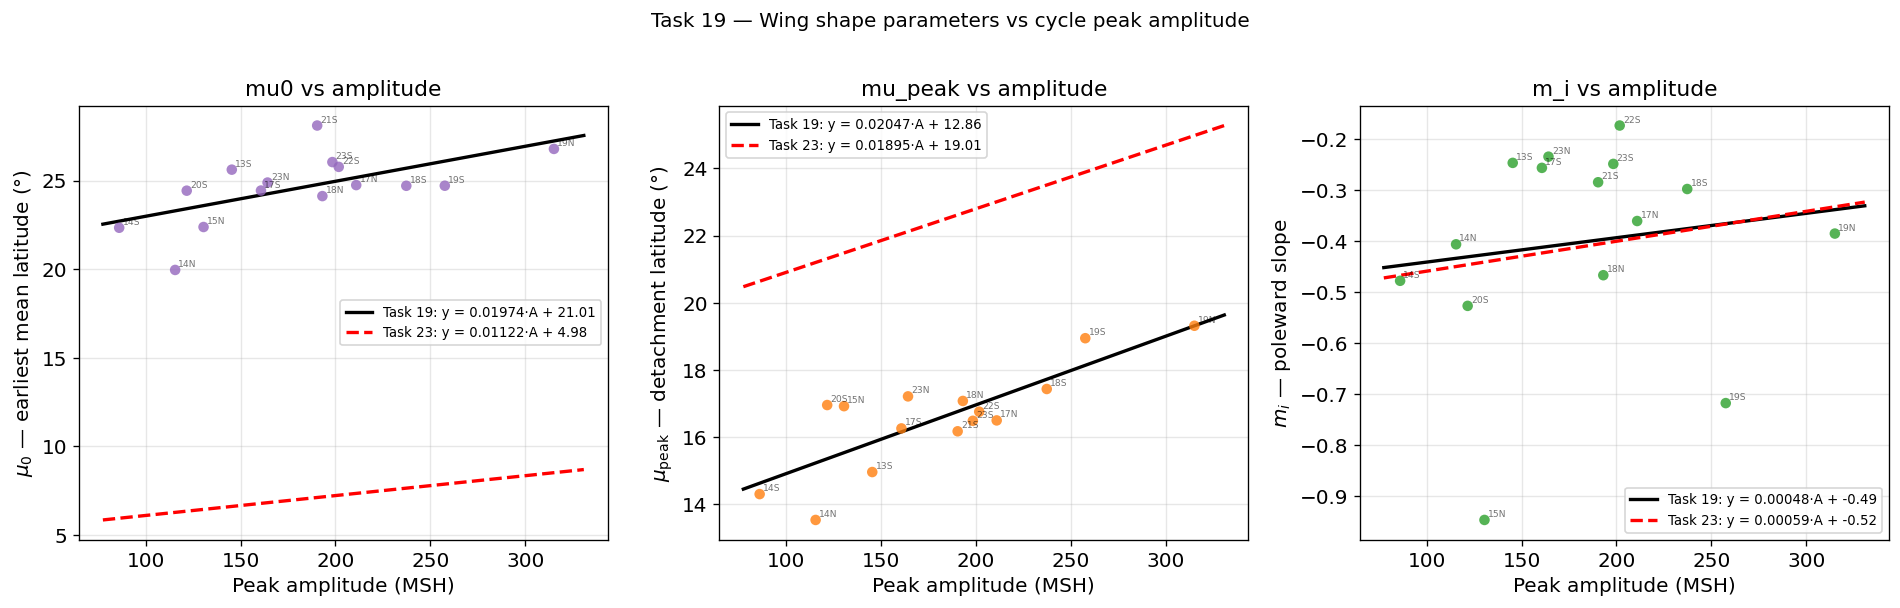

In [44]:

### Uncomment the following lines to create the scatter plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (col, ylabel, color) in zip(axes, param_info):
    vals = df19[["amplitude", col]].dropna()
    x, y = vals["amplitude"].values, vals[col].values

    amp_grid_19 = np.linspace(x.min() * 0.9, x.max() * 1.05, 200)
    ax.scatter(x, y, color=color, s=40, alpha=0.80, edgecolors="none", zorder=3)
    ax.plot(amp_grid_19, linear_fit(amp_grid_19, fit_results_19[col][0], fit_results_19[col][1]),
            color="black", linewidth=2,
            label=f"Task 19: y = {fit_results_19[col][0]:.5f}·A + {fit_results_19[col][1]:.2f}")
    ax.plot(amp_grid_19, linear_fit(amp_grid_19, fit_results_23[col][0], fit_results_23[col][1]),
            color="red", linewidth=2, linestyle="--",
            label=f"Task 23: y = {fit_results_23[col][0]:.5f}·A + {fit_results_23[col][1]:.2f}")

    for _, row in df19.iterrows():
        if pd.notna(row["amplitude"]) and pd.notna(row[col]):
            ax.annotate(f"{int(row['cycle'])}{row['hemisphere'][0].upper()}",
                        (row["amplitude"], row[col]),
                        fontsize=5.5, alpha=0.55, xytext=(2, 2),
                        textcoords="offset points")

    ax.set_xlabel("Peak amplitude (MSH)")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{col} vs amplitude")
    ax.legend(fontsize=8)

plt.suptitle("Task 19 — Wing shape parameters vs cycle peak amplitude", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()


#### Plotting Gaussians and Creating a Synthetic Wing

Choose the cycle and hemisphere to analyze

In [45]:
cycle_number = 17
hemisphere = "south"

##### Plot the data and the spread per year

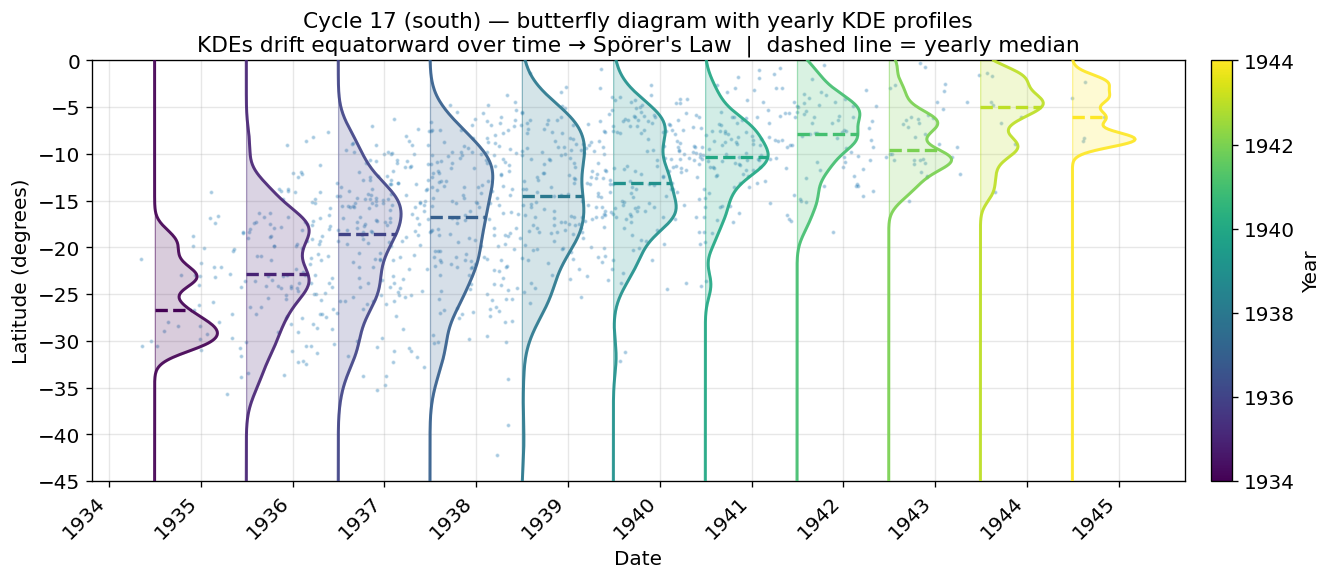

Cycle 17 (south) — yearly median and KDE peak latitudes:
  1934: median = -26.7°   KDE peak = -29.2°
  1935: median = -22.8°   KDE peak = -18.2°
  1936: median = -18.5°   KDE peak = -16.4°
  1937: median = -16.7°   KDE peak = -12.5°
  1938: median = -14.5°   KDE peak = -9.6°
  1939: median = -13.1°   KDE peak = -15.7°
  1940: median = -10.4°   KDE peak = -10.1°
  1941: median = -7.8°   KDE peak = -5.7°
  1942: median = -9.6°   KDE peak = -10.7°
  1943: median = -5.0°   KDE peak = -4.5°
  1944: median = -6.1°   KDE peak = -8.4°


In [46]:
# Task 8: KDE evolution through a solar cycle — butterfly diagram + per-year KDE profiles
import matplotlib.dates as mdates
from scipy.stats import gaussian_kde

# Filter to cycle + hemisphere
mask = (df["CYCLE"] == cycle_number) & (df["hemisphere"] == hemisphere)
df_cyc_hemi = df[mask].copy()

years_in_cycle = sorted(df_cyc_hemi["year"].unique())
n_years = len(years_in_cycle)

# Colour map: early years → purple, late years → yellow (viridis is perceptually uniform
# and appropriate for a strictly increasing quantity like time)
cmap = plt.get_cmap("viridis", n_years)

# Latitude grid for evaluating KDEs (stay within the Spörer zone)
lat_grid = np.linspace(0, 45, 300) if hemisphere == "north" else np.linspace(-45, 0, 300)

# How wide (in days) should the tallest KDE peak be?
# ~250 days ≈ 2/3 of a year — wide enough to read, narrow enough not to overlap badly
kde_width_days = 250

fig, ax = plt.subplots(figsize=(12, 5))

# --- Background: butterfly diagram scatter ---
scatter_color = "tab:red" if hemisphere == "north" else "tab:blue"
ax.scatter(df_cyc_hemi["date"], df_cyc_hemi["latitude"],
           s=2, color=scatter_color, alpha=0.25, zorder=1, label="Sunspot groups")

# --- Foreground: per-year KDE profiles drawn vertically ---
for i, yr in enumerate(years_in_cycle):
    yr_lats = df_cyc_hemi.loc[df_cyc_hemi["year"] == yr, "latitude"].values
    if len(yr_lats) < 5:          # skip years with too few observations
        continue

    kde = gaussian_kde(yr_lats, bw_method=0.3)
    kde_vals = kde(lat_grid)

    # Normalise so the peak reaches kde_width_days on the x-axis
    kde_scaled = kde_vals / kde_vals.max() * kde_width_days

    # Anchor each profile at July 1 of that year
    center = pd.Timestamp(f"{int(yr)}-07-01")
    x_curve  = [center + pd.Timedelta(days=float(v)) for v in kde_scaled]
    x_anchor = [center] * len(lat_grid)

    color = cmap(i)
    ax.plot(x_curve, lat_grid, color=color, linewidth=1.8, alpha=0.9, zorder=3)
    ax.fill_betweenx(lat_grid, x_anchor, x_curve,
                     color=color, alpha=0.20, zorder=2)
    # Thin vertical baseline at the anchor date
    ax.axvline(center, color=color, linewidth=0.5, alpha=0.4, zorder=1)

    # Horizontal line at the yearly median latitude, extending to the KDE curve edge
    median_lat = np.median(yr_lats)
    kde_at_median = float(kde(np.array([median_lat]))[0])
    kde_at_median_scaled = kde_at_median / kde_vals.max() * kde_width_days
    x_median_end = center + pd.Timedelta(days=kde_at_median_scaled)
    ax.plot([center, x_median_end], [median_lat, median_lat],
            color=color, linewidth=2, linestyle="--", alpha=1.0, zorder=4)

# --- Colour bar (time axis) ---
sm = plt.cm.ScalarMappable(cmap="viridis",
                            norm=plt.Normalize(vmin=years_in_cycle[0],
                                               vmax=years_in_cycle[-1]))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label("Year")

ax.set_title(
    f"Cycle {cycle_number} ({hemisphere}) — butterfly diagram with yearly KDE profiles\n"
    f"KDEs drift equatorward over time → Spörer's Law  |  dashed line = yearly median"
)
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (degrees)")
ax.set_ylim((0, 45) if hemisphere == "north" else (-45, 0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

# --- Numeric summary: KDE peak latitude per year (tracks Spörer drift) ---
print(f"Cycle {cycle_number} ({hemisphere}) — yearly median and KDE peak latitudes:")
for i, yr in enumerate(years_in_cycle):
    yr_lats = df_cyc_hemi.loc[df_cyc_hemi["year"] == yr, "latitude"].values
    if len(yr_lats) < 5:
        continue
    kde = gaussian_kde(yr_lats, bw_method=0.3)
    peak_lat   = lat_grid[np.argmax(kde(lat_grid))]
    median_lat = np.median(yr_lats)
    print(f"  {int(yr)}: median = {median_lat:.1f}°   KDE peak = {peak_lat:.1f}°")


##### Plot task 19's gaussians

Cycle 17 (south): peak amplitude = 161 MSH
  Predicted μ₀     = 24.19°   (earliest significant emergence latitude)
  Predicted μ_peak = 16.15°   (detachment latitude)
  Predicted m_i    = -0.4120    (poleward slope)

Synthetic years: [1934 1935 1936 1937 1938 1939 1940 1941 1942 1943 1944]  (μ range: 7.4°–24.0°)


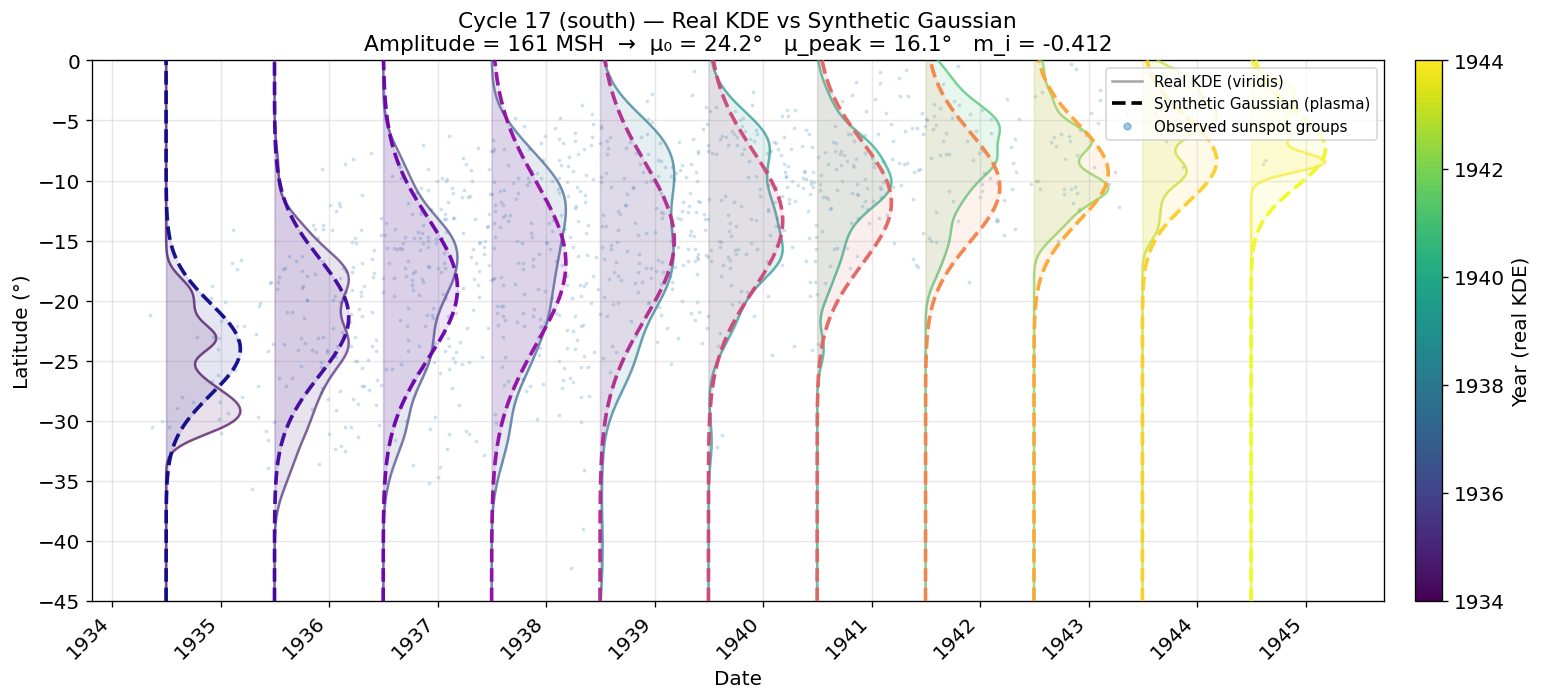

In [47]:

# Task 20: Putting It All Together — Synthesizing a Wing from Amplitude
# cycle_number and hemisphere are set in the cell above (default: 24 / north)

# ── Step 2: predict shape parameters from amplitude ───────────────────────
amp_20 = amp_lookup.get((cycle_number, hemisphere))
print(f"Cycle {cycle_number} ({hemisphere}): peak amplitude = {amp_20:.0f} MSH")

mu0_pred    = linear_fit(amp_20, *fit_results_19["mu0"])
mupeak_pred = linear_fit(amp_20, *fit_results_19["mu_peak"])
mi_pred     = linear_fit(amp_20, *fit_results_19["m_i"])
print(f"  Predicted μ₀     = {mu0_pred:.2f}°   (earliest significant emergence latitude)")
print(f"  Predicted μ_peak = {mupeak_pred:.2f}°   (detachment latitude)")
print(f"  Predicted m_i    = {mi_pred:.4f}    (poleward slope)")

# ── Step 3: annual mean latitudes from the universal path ─────────────────
t0_ref_20 = t0_refined[(cycle_number, hemisphere)]
df_sel_20  = df[(df["CYCLE"] == cycle_number) & (df["hemisphere"] == hemisphere)
                & df["tau_refined"].notna()]
tau_min_20 = df_sel_20["tau_refined"].min()
tau_max_20 = df_sel_20["tau_refined"].max()

# Use the same years as the KDE plot — guarantees 1:1 correspondence
year_ann = np.array(years_in_cycle)
tau_ann  = (year_ann + 0.5) - t0_ref_20
mu_ann   = exp_decay(tau_ann, a_mu_univ, b_mu_univ)
print(f"\nSynthetic years: {year_ann}  (μ range: {mu_ann.min():.1f}°–{mu_ann.max():.1f}°)")

# ── Steps 4–6: σ per year from the piecewise-linear model ────────────────
sigma_ann = np.array([
    piecewise_linear_wing(mu, m_shared_fit, b_shared_fit, mupeak_pred, mi_pred)
    for mu in mu_ann
])

# ── Step 7: overlay synthetic Gaussians on the real KDE butterfly diagram ─
sign     = +1 if hemisphere == "north" else -1
cmap_syn = plt.get_cmap("plasma", len(year_ann))

fig, ax = plt.subplots(figsize=(14, 6))

# Background scatter
sc_color = "tab:red" if hemisphere == "north" else "tab:blue"
ax.scatter(df_cyc_hemi["date"], df_cyc_hemi["latitude"],
           s=2, color=sc_color, alpha=0.15, zorder=1)

# Real KDE profiles (viridis — redrawn from the cell above)
for i, yr in enumerate(years_in_cycle):
    yr_lats = df_cyc_hemi.loc[df_cyc_hemi["year"] == yr, "latitude"].values
    if len(yr_lats) < 5:
        continue
    kde_obj  = gaussian_kde(yr_lats, bw_method=0.3)
    kde_vals = kde_obj(lat_grid)
    kde_sc   = kde_vals / kde_vals.max() * kde_width_days
    center   = pd.Timestamp(f"{int(yr)}-07-01")
    x_curve  = [center + pd.Timedelta(days=float(v)) for v in kde_sc]
    col_r    = cmap(i)   # viridis from the cell above
    ax.plot(x_curve, lat_grid, color=col_r, linewidth=1.5, alpha=0.65, zorder=3)
    ax.fill_betweenx(lat_grid, [center] * len(lat_grid), x_curve,
                     color=col_r, alpha=0.12, zorder=2)

# Synthetic Gaussian profiles (plasma, dashed)
for j, (yr, mu, sigma) in enumerate(zip(year_ann, mu_ann, sigma_ann)):
    if sigma <= 0:
        continue
    center_lat = sign * mu   # positive for north, negative for south
    gauss_vals = sp_norm.pdf(lat_grid, loc=center_lat, scale=sigma)
    if gauss_vals.max() == 0:
        continue
    gauss_sc = gauss_vals / gauss_vals.max() * kde_width_days
    center   = pd.Timestamp(f"{int(yr)}-07-01")
    x_curve  = [center + pd.Timedelta(days=float(v)) for v in gauss_sc]
    col_s    = cmap_syn(j)
    ax.plot(x_curve, lat_grid, color=col_s, linewidth=2.2, linestyle="--",
            alpha=0.95, zorder=5)
    ax.fill_betweenx(lat_grid, [center] * len(lat_grid), x_curve,
                     color=col_s, alpha=0.10, zorder=4)

# Colour bar for real KDE (viridis)
sm_r = plt.cm.ScalarMappable(cmap="viridis",
    norm=plt.Normalize(vmin=years_in_cycle[0], vmax=years_in_cycle[-1]))
sm_r.set_array([])
cbar = fig.colorbar(sm_r, ax=ax, pad=0.02)
cbar.set_label("Year (real KDE)")

# Legend
leg_elements = [
    Line2D([0], [0], color="gray",  linewidth=1.5, alpha=0.7,
           label="Real KDE (viridis)"),
    Line2D([0], [0], color="black", linewidth=2.2, linestyle="--",
           label="Synthetic Gaussian (plasma)"),
    Line2D([0], [0], color=sc_color, marker="o", markersize=4,
           linestyle="None", alpha=0.4, label="Observed sunspot groups"),
]
ax.legend(handles=leg_elements, loc="upper right", fontsize=9)

ax.set_title(
    f"Cycle {cycle_number} ({hemisphere}) — Real KDE vs Synthetic Gaussian\n"
    f"Amplitude = {amp_20:.0f} MSH  →  μ₀ = {mu0_pred:.1f}°   "
    f"μ_peak = {mupeak_pred:.1f}°   m_i = {mi_pred:.3f}"
)
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (°)")
ax.set_ylim((0, 45) if hemisphere == "north" else (-45, 0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()


##### Plot task 23's gaussians

Cycle 17 (south): peak amplitude = 161 MSH
  Predicted μ₀     = 6.78°   (earliest significant emergence latitude)
  Predicted μ_peak = 22.05°   (detachment latitude)
  Predicted m_i    = -0.4232    (poleward slope)

Synthetic years: [1934 1935 1936 1937 1938 1939 1940 1941 1942 1943 1944]  (μ range: 7.4°–24.0°)


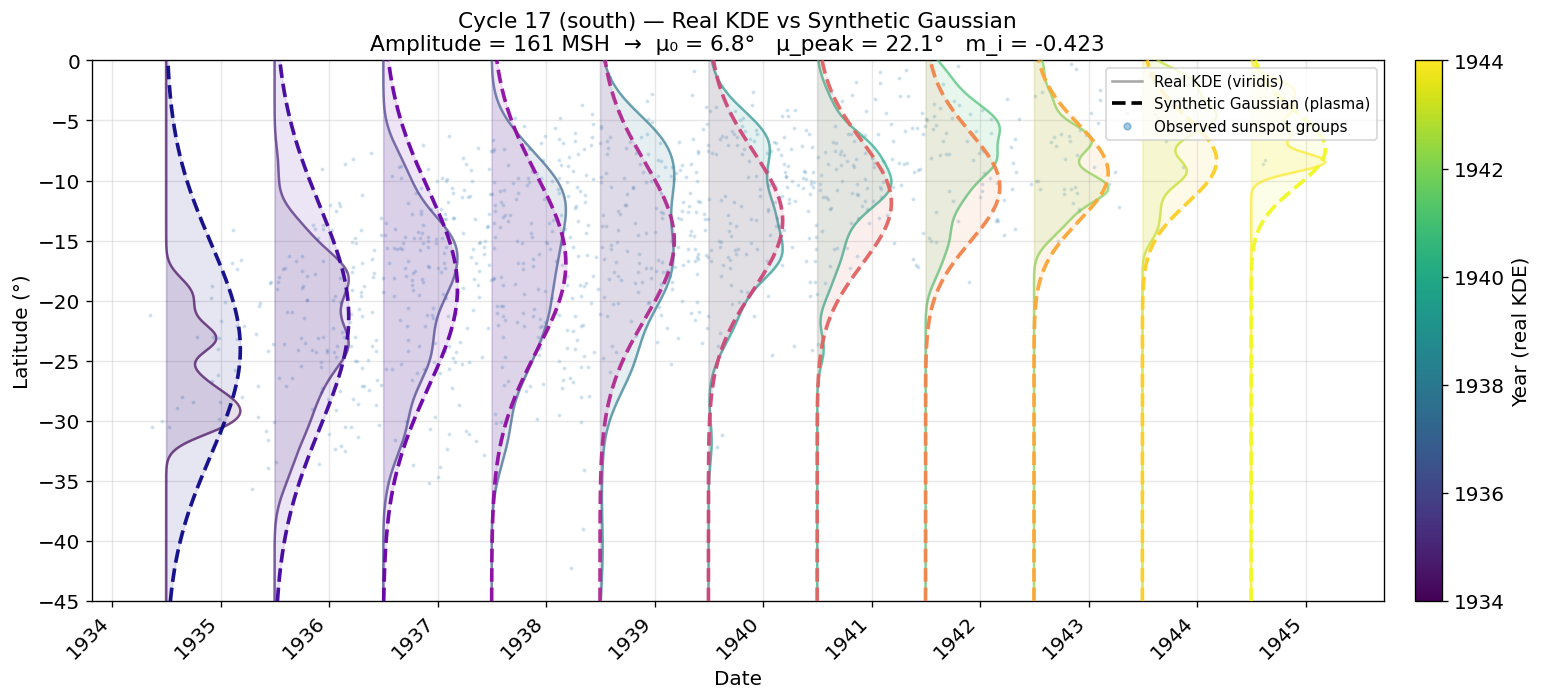

In [48]:

# Task 20: Putting It All Together — Synthesizing a Wing from Amplitude
# cycle_number and hemisphere are set in the cell above (default: 24 / north)

# ── Step 2: predict shape parameters from amplitude ───────────────────────
amp_20 = amp_lookup.get((cycle_number, hemisphere))
print(f"Cycle {cycle_number} ({hemisphere}): peak amplitude = {amp_20:.0f} MSH")

mu0_pred    = linear_fit(amp_20, *fit_results_23["mu0"])
mupeak_pred = linear_fit(amp_20, *fit_results_23["mu_peak"])
mi_pred     = linear_fit(amp_20, *fit_results_23["m_i"])
print(f"  Predicted μ₀     = {mu0_pred:.2f}°   (earliest significant emergence latitude)")
print(f"  Predicted μ_peak = {mupeak_pred:.2f}°   (detachment latitude)")
print(f"  Predicted m_i    = {mi_pred:.4f}    (poleward slope)")

# ── Step 3: annual mean latitudes from the universal path ─────────────────
t0_ref_20 = t0_refined[(cycle_number, hemisphere)]
df_sel_20  = df[(df["CYCLE"] == cycle_number) & (df["hemisphere"] == hemisphere)
                & df["tau_refined"].notna()]
tau_min_20 = df_sel_20["tau_refined"].min()
tau_max_20 = df_sel_20["tau_refined"].max()

# Use the same years as the KDE plot — guarantees 1:1 correspondence
year_ann = np.array(years_in_cycle)
tau_ann  = (year_ann + 0.5) - t0_ref_20
mu_ann   = exp_decay(tau_ann, a_mu_univ, b_mu_univ)
print(f"\nSynthetic years: {year_ann}  (μ range: {mu_ann.min():.1f}°–{mu_ann.max():.1f}°)")

# ── Steps 4–6: σ per year from the piecewise-linear model ────────────────
sigma_ann = np.array([
    piecewise_linear_wing(mu, m_shared_fit, b_shared_fit, mupeak_pred, mi_pred)
    for mu in mu_ann
])

# ── Step 7: overlay synthetic Gaussians on the real KDE butterfly diagram ─
sign     = +1 if hemisphere == "north" else -1
cmap_syn = plt.get_cmap("plasma", len(year_ann))

fig, ax = plt.subplots(figsize=(14, 6))

# Background scatter
sc_color = "tab:red" if hemisphere == "north" else "tab:blue"
ax.scatter(df_cyc_hemi["date"], df_cyc_hemi["latitude"],
           s=2, color=sc_color, alpha=0.15, zorder=1)

# Real KDE profiles (viridis — redrawn from the cell above)
for i, yr in enumerate(years_in_cycle):
    yr_lats = df_cyc_hemi.loc[df_cyc_hemi["year"] == yr, "latitude"].values
    if len(yr_lats) < 5:
        continue
    kde_obj  = gaussian_kde(yr_lats, bw_method=0.3)
    kde_vals = kde_obj(lat_grid)
    kde_sc   = kde_vals / kde_vals.max() * kde_width_days
    center   = pd.Timestamp(f"{int(yr)}-07-01")
    x_curve  = [center + pd.Timedelta(days=float(v)) for v in kde_sc]
    col_r    = cmap(i)   # viridis from the cell above
    ax.plot(x_curve, lat_grid, color=col_r, linewidth=1.5, alpha=0.65, zorder=3)
    ax.fill_betweenx(lat_grid, [center] * len(lat_grid), x_curve,
                     color=col_r, alpha=0.12, zorder=2)

# Synthetic Gaussian profiles (plasma, dashed)
for j, (yr, mu, sigma) in enumerate(zip(year_ann, mu_ann, sigma_ann)):
    if sigma <= 0:
        continue
    center_lat = sign * mu   # positive for north, negative for south
    gauss_vals = sp_norm.pdf(lat_grid, loc=center_lat, scale=sigma)
    if gauss_vals.max() == 0:
        continue
    gauss_sc = gauss_vals / gauss_vals.max() * kde_width_days
    center   = pd.Timestamp(f"{int(yr)}-07-01")
    x_curve  = [center + pd.Timedelta(days=float(v)) for v in gauss_sc]
    col_s    = cmap_syn(j)
    ax.plot(x_curve, lat_grid, color=col_s, linewidth=2.2, linestyle="--",
            alpha=0.95, zorder=5)
    ax.fill_betweenx(lat_grid, [center] * len(lat_grid), x_curve,
                     color=col_s, alpha=0.10, zorder=4)

# Colour bar for real KDE (viridis)
sm_r = plt.cm.ScalarMappable(cmap="viridis",
    norm=plt.Normalize(vmin=years_in_cycle[0], vmax=years_in_cycle[-1]))
sm_r.set_array([])
cbar = fig.colorbar(sm_r, ax=ax, pad=0.02)
cbar.set_label("Year (real KDE)")

# Legend
leg_elements = [
    Line2D([0], [0], color="gray",  linewidth=1.5, alpha=0.7,
           label="Real KDE (viridis)"),
    Line2D([0], [0], color="black", linewidth=2.2, linestyle="--",
           label="Synthetic Gaussian (plasma)"),
    Line2D([0], [0], color=sc_color, marker="o", markersize=4,
           linestyle="None", alpha=0.4, label="Observed sunspot groups"),
]
ax.legend(handles=leg_elements, loc="upper right", fontsize=9)

ax.set_title(
    f"Cycle {cycle_number} ({hemisphere}) — Real KDE vs Synthetic Gaussian\n"
    f"Amplitude = {amp_20:.0f} MSH  →  μ₀ = {mu0_pred:.1f}°   "
    f"μ_peak = {mupeak_pred:.1f}°   m_i = {mi_pred:.3f}"
)
ax.set_xlabel("Date")
ax.set_ylabel("Latitude (°)")
ax.set_ylim((0, 45) if hemisphere == "north" else (-45, 0))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()


##### Create a synthetic butterfly wing from the optimized parameters

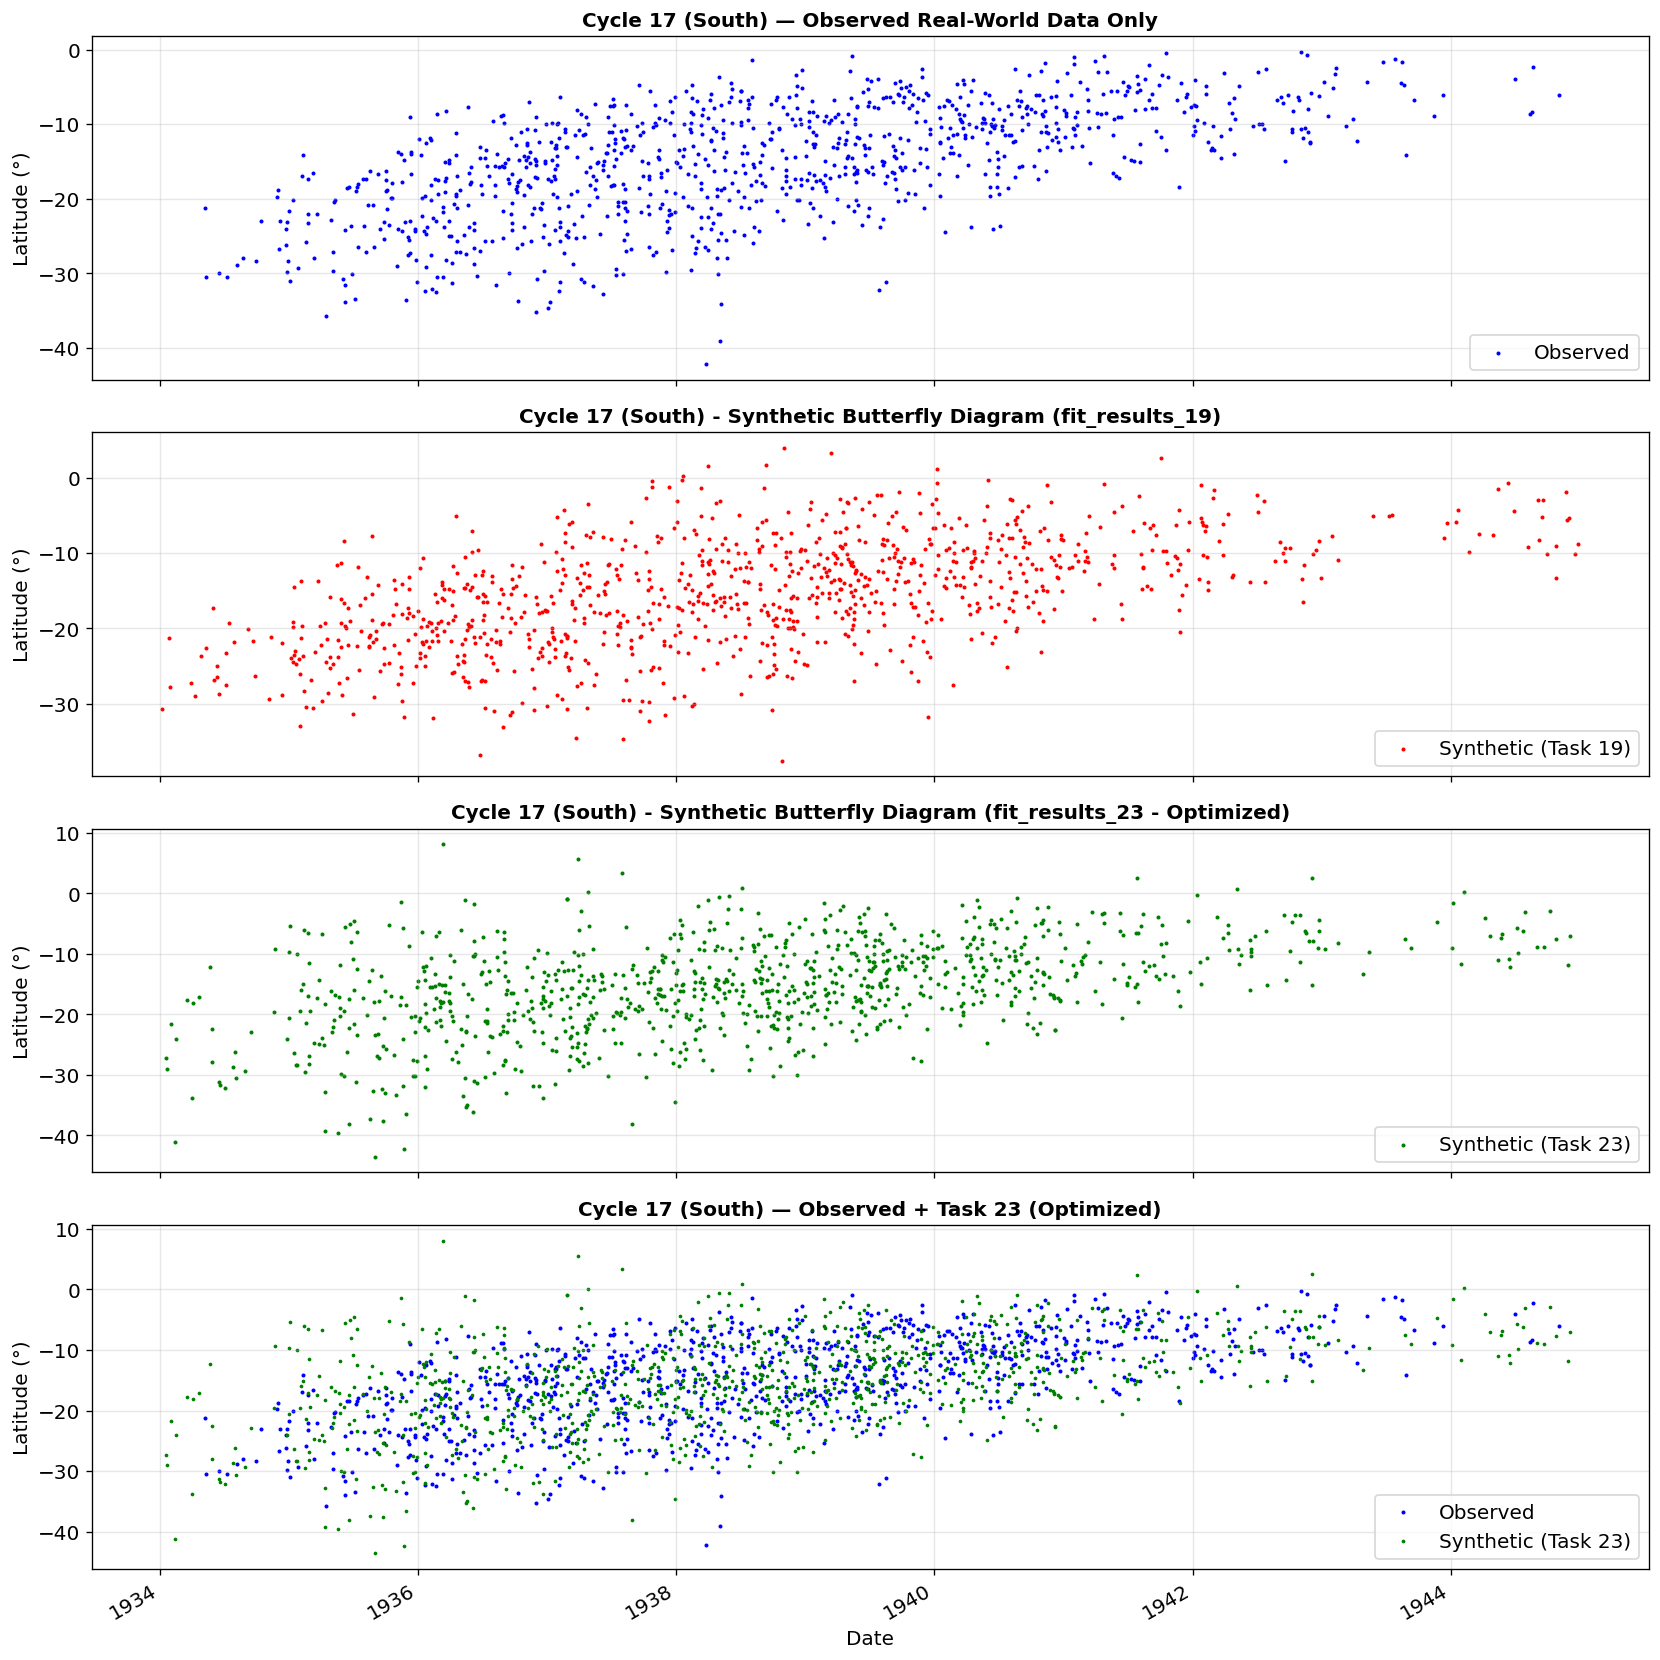


Synthetic Butterfly Diagram Comparison
Cycle: 17 (South)

Task 19 (fit_results_19):
  Generated:   1018 synthetic sunspots

Task 23 (fit_results_23 - Optimized):
  Generated:   1018 synthetic sunspots
  Observed:    1018 sunspots


In [49]:

## Comprehensive visualization comparing observed and both synthetic models - mostly generated by Calude Haiku 4.5

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Prepare real data ──────────────────────────────────────────────────────
# Compute annual mean of the 12-month smoothed total area as proxy for activity
if hemi == 'north':
    yearly_activity = smooth_north.resample('YE').mean()
elif hemi == 'south':
    yearly_activity = smooth_south.resample('YE').mean()

yearly_activity.index = yearly_activity.index.year  # Convert to year int

# Set total number of synthetic sunspots to match observed count for this hemisphere
N_SYNTHETIC = len(df_cyc_hemi)

# Normalize yearly activity to get sampling weights, only for years in the cycle
common_years = yearly_activity.index.intersection(year_ann)
weights = yearly_activity.loc[common_years] / yearly_activity.loc[common_years].sum()

# Use multinomial sampling to get exact integer counts summing to N_SYNTHETIC
n_samples = np.random.multinomial(N_SYNTHETIC, weights.values)
n_samples_per_year = pd.Series(n_samples, index=common_years)

# ── Function to generate synthetic data from fit results ───────────────────
def generate_synthetic_data(year_list, mu_vals, sigma_vals):
    """Generate synthetic butterfly diagram from fit results."""
    synthetic_lats = []
    synthetic_dates = []
    
    for i, yr in enumerate(year_list):
        if yr in n_samples_per_year.index:
            n = n_samples_per_year.loc[yr]
        else:
            n = 0
        mu = mu_vals[i]
        sigma = sigma_vals[i]
        if sigma <= 0:
            continue
        lats = rng.normal(mu, sigma, n)
        start = pd.Timestamp(year=int(yr), month=1, day=1)
        dates = start + pd.to_timedelta(rng.random(n) * 365.25, unit='D')
        synthetic_lats.extend(lats)
        synthetic_dates.extend(dates)
    
    synthetic_dates = pd.to_datetime(synthetic_dates)
    synthetic_lats = np.array(synthetic_lats)
    return synthetic_dates, synthetic_lats

# ── Generate synthetic data for fit_results_19 ────────────────────────────
amp_19 = amp_lookup.get((cycle_number, hemisphere))
mu0_pred_19    = linear_fit(amp_19, *fit_results_19["mu0"])
mupeak_pred_19 = linear_fit(amp_19, *fit_results_19["mu_peak"])
mi_pred_19     = linear_fit(amp_19, *fit_results_19["m_i"])

mu_ann_19 = exp_decay((year_ann + 0.5) - t0_refined[(cycle_number, hemisphere)], 
                       a_mu_univ, b_mu_univ)
sigma_ann_19 = np.array([
    piecewise_linear_wing(mu, m_shared_fit, b_shared_fit, mupeak_pred_19, mi_pred_19)
    for mu in mu_ann_19
])

synthetic_dates_19, synthetic_lats_19 = generate_synthetic_data(
    year_ann, mu_ann_19, sigma_ann_19
)
if hemisphere == 'south':
    synthetic_lats_19 = -synthetic_lats_19

# ── Generate synthetic data for fit_results_23 ────────────────────────────
amp_23 = amp_lookup.get((cycle_number, hemisphere))
mu0_pred_23    = linear_fit(amp_23, *fit_results_23["mu0"])
mupeak_pred_23 = linear_fit(amp_23, *fit_results_23["mu_peak"])
mi_pred_23     = linear_fit(amp_23, *fit_results_23["m_i"])

mu_ann_23 = exp_decay((year_ann + 0.5) - t0_refined[(cycle_number, hemisphere)], 
                       a_mu_univ, b_mu_univ)
sigma_ann_23 = np.array([
    piecewise_linear_wing(mu, m_shared_fit, b_shared_fit, mupeak_pred_23, mi_pred_23)
    for mu in mu_ann_23
])

synthetic_dates_23, synthetic_lats_23 = generate_synthetic_data(
    year_ann, mu_ann_23, sigma_ann_23
)
if hemisphere == 'south':
    synthetic_lats_23 = -synthetic_lats_23

# ── Create 4-panel figure ──────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)

# Panel 1: Real world data only
ax = axes[0]
ax.scatter(pd.to_datetime(df_cyc_hemi['date']), df_cyc_hemi['latitude'], 
           alpha=1, s=2, color="blue", label="Observed")
ax.set_ylabel('Latitude (°)')
ax.set_title(f'Cycle {cycle_number} ({hemisphere.capitalize()}) — Observed Real-World Data Only', 
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
if hemisphere == 'north':
    ax.legend(loc='upper right')
elif hemisphere == 'south':
    ax.legend(loc='lower right')

# Panel 2: Synthetic wing from fit_results_19 only
ax = axes[1]
ax.scatter(synthetic_dates_19, synthetic_lats_19, alpha=1, s=2, 
           color='red', label='Synthetic (Task 19)')
ax.set_ylabel('Latitude (°)')
ax.set_title(f'Cycle {cycle_number} ({hemisphere.capitalize()}) - Synthetic Butterfly Diagram (fit_results_19)', 
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
if hemisphere == 'north':
    ax.legend(loc='upper right')
elif hemisphere == 'south':
    ax.legend(loc='lower right')

# Panel 3: Synthetic wing from fit_results_23 only
ax = axes[2]
ax.scatter(synthetic_dates_23, synthetic_lats_23, alpha=1, s=2, 
           color='green', label='Synthetic (Task 23)')
ax.set_ylabel('Latitude (°)')
ax.set_title(f'Cycle {cycle_number} ({hemisphere.capitalize()}) - Synthetic Butterfly Diagram (fit_results_23 - Optimized)', 
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
if hemisphere == 'north':
    ax.legend(loc='upper right')
elif hemisphere == 'south':
    ax.legend(loc='lower right')

# Panel 4: Observed and Task 23 optimized
ax = axes[3]
ax.scatter(pd.to_datetime(df_cyc_hemi['date']), df_cyc_hemi['latitude'], 
           alpha=1, s=2, color='blue', label='Observed')
ax.scatter(synthetic_dates_23, synthetic_lats_23, alpha=1, s=1.5, 
           color='green', label='Synthetic (Task 23)')
ax.set_xlabel('Date')
ax.set_ylabel('Latitude (°)')
ax.set_title(f'Cycle {cycle_number} ({hemisphere.capitalize()}) — Observed + Task 23 (Optimized)', 
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
if hemisphere == 'north':
    ax.legend(loc='upper right')
elif hemisphere == 'south':
    ax.legend(loc='lower right')

# Format x-axis for all panels
for ax in axes:
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"\n{'='*70}")
print(f"Synthetic Butterfly Diagram Comparison")
print(f"{'='*70}")
print(f"Cycle: {cycle_number} ({hemisphere.capitalize()})")
print(f"\nTask 19 (fit_results_19):")
print(f"  Generated:  {len(synthetic_lats_19):5d} synthetic sunspots")
print(f"\nTask 23 (fit_results_23 - Optimized):")
print(f"  Generated:  {len(synthetic_lats_23):5d} synthetic sunspots")
print(f"  Observed:   {len(df_cyc_hemi):5d} sunspots")
print(f"{'='*70}")
